# Simple Linear Regression From Scratch

This notebook implements Simple Linear Regression using the closed-form Ordinary Least Squares solution.

No pre-built linear regression estimator is used for model fitting.

The implementation will:

1. Load the Advertising dataset.
2. Select TV advertising expenditure as the feature.
3. Select Sales as the target.
4. Split the data into training and testing sets.
5. Fit a Simple Linear Regression model using OLS.
6. Generate predictions.
7. Evaluate the model using MAE, MSE, RMSE and R².
8. Visualize the fitted regression line.

In [15]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [16]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

str(PROJECT_ROOT)

'/Users/shyamverma/ml_projects/slr_from_ols'

In [17]:
df = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [18]:
df.columns = ["Id", "TV", "Radio", "Newspaper", "Sales"]

In [19]:
df = df.drop(columns="Id")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [20]:
X = df["TV"].values
y = df["Sales"].values

In [21]:
print("X Shape: ", X.shape)
print("y Shape: ", y.shape)

X Shape:  (200,)
y Shape:  (200,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
# Initializing our Simple Linear Regression Class
from src.linear_regression import SimpleLinearRegression
from src.metrics import mae, mse, rmse, r2_score

model = SimpleLinearRegression()

In [25]:
# As we haven't trained or fit our model that's why coeffienct and intercept is coming out to be None
print(model.coef_)
print(model.intercept_)

None
None


In [26]:
model.fit(X_train, y_train)

In [28]:
# So here we got the model intercept and coefficient that are m and c
print("Slope: ", model.coef_)
print("Intercept: ", model.intercept_)

Slope:  0.046529733705443346
Intercept:  7.119638430592953


In [29]:
y_pred = model.predict(X_test)

In [30]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": y_test - y_pred
})

results.head(10)

,Actual,Predicted,Residual
0,16.9,14.717944,2.182056
1,22.4,16.211548,6.188452
2,21.4,20.748197,0.651803
3,7.3,7.664036,-0.364036
4,24.7,17.370139,7.329861
5,12.6,10.614021,1.985979
6,22.3,17.207285,5.092715
7,8.4,9.446125,-1.046125
8,11.5,17.467851,-5.967851
9,14.9,15.266995,-0.366995


In [31]:
mae_value = mae(y_test, y_pred)
mse_value = mse(y_test, y_pred)
rmse_value = rmse(y_test, y_pred)
r2_value = r2_score(y_test, y_pred)

In [32]:
print(f"MAE: {mae_value:.4f}")
print(f"MSE: {mse_value:.4f}")
print(f"RMSE: {rmse_value:.4f}")
print(f"R2: {r2_value:.4f}")

MAE: 2.4444
MSE: 10.2047
RMSE: 3.1945
R2: 0.6767


In [33]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Value": [mae_value, mse_value, rmse_value, r2_value]
})

metrics

,Metric,Value
0,MAE,2.444420
1,MSE,10.204654
2,RMSE,3.194472
3,R2,0.676695


In [34]:
sort_idx = np.argsort(X_test)

X_test_sorted = X_test[sort_idx]
y_pred_sorted = y_pred[sort_idx]

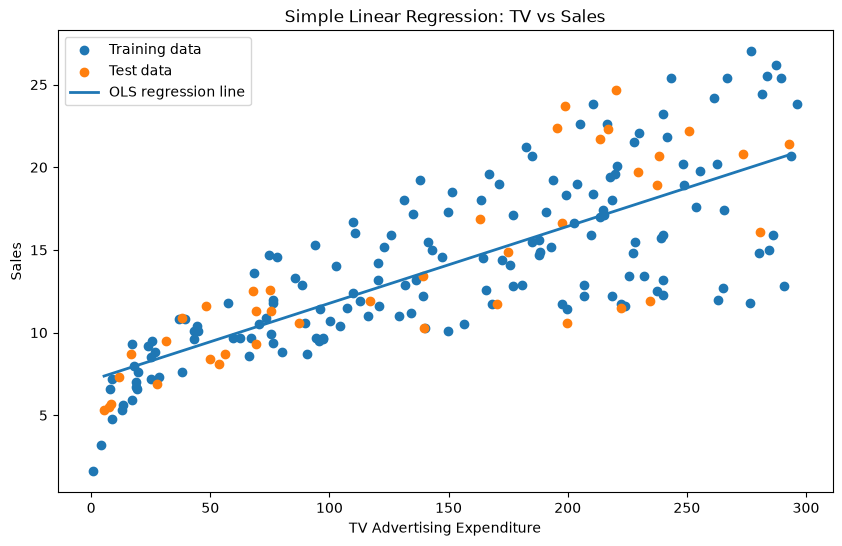

In [35]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_train,
    y_train,
    label="Training data"
)

plt.scatter(
    X_test,
    y_test,
    label="Test data"
)

plt.plot(
    X_test_sorted,
    y_pred_sorted,
    linewidth=2,
    label="OLS regression line"
)

plt.xlabel("TV Advertising Expenditure")
plt.ylabel("Sales")
plt.title("Simple Linear Regression: TV vs Sales")
plt.legend()

plt.show()

In [36]:
residuals = y_test - y_pred

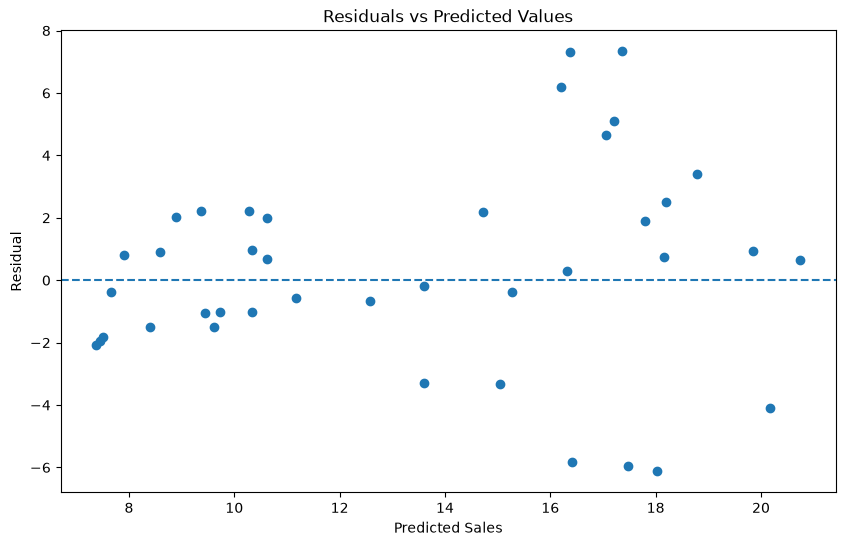

In [37]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

In [38]:
y_train_pred = model.predict(X_train)

train_residuals = y_train - y_train_pred

print("Sum of training residuals: ", np.sum(train_residuals))

Sum of training residuals:  2.575717417130363e-13


In [39]:
orthogonality = np.sum(
    X_train * train_residuals
)

print("Σ(xᵢeᵢ):", orthogonality)

Σ(xᵢeᵢ): 3.7061909097246826e-11


## Coefficient Interpretation

The estimated slope represents the change in the model's predicted Sales associated with a one-unit increase in TV advertising expenditure, within the observed data and the fitted linear specification.

This is an associational/model-based interpretation and should not be interpreted as a causal effect.

In [40]:
manual_predictions = model.intercept_ + model.coef_ * X_test

In [41]:
np.allclose(y_pred, manual_predictions)

True

In [42]:
summary = {
    "Intercept": model.intercept_,
    "Slope": model.coef_,
    "MAE": mae_value,
    "MSE": mse_value,
    "RMSE": rmse_value,
    "R2": r2_value
}

summary

{'Intercept': np.float64(7.119638430592953),
 'Slope': np.float64(0.046529733705443346),
 'MAE': np.float64(2.444420003751042),
 'MSE': np.float64(10.204654118800956),
 'RMSE': np.float64(3.194472431998898),
 'R2': np.float64(0.6766954295627076)}